# 01 — Análise Exploratória (EDA)
**Objetivo:** entender a distribuição dos dados, identificar valores faltantes, correlações e outliers antes de qualquer modelagem.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Carregamento e visão geral

In [2]:
train = pd.read_csv('../data/treino.csv')
test  = pd.read_csv('../data/teste_publico.csv')

print(f'Treino : {train.shape}  |  Teste: {test.shape}')
print(f'Colunas treino: {list(train.columns)}')

Treino : (1168, 81)  |  Teste: (1459, 80)
Colunas treino: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Enclos

In [3]:
# Tipos de dados e contagem de nulos
info_df = pd.DataFrame({
    'dtype': train.dtypes,
    'n_null': train.isnull().sum(),
    'pct_null': (train.isnull().mean() * 100).round(2)
}).sort_values('n_null', ascending=False)
print(info_df[info_df.n_null > 0])

                dtype  n_null  pct_null
PoolQC            str    1162     99.49
MiscFeature       str    1122     96.06
Alley             str    1094     93.66
Fence             str     935     80.05
MasVnrType        str     683     58.48
FireplaceQu       str     547     46.83
LotFrontage   float64     217     18.58
GarageQual        str      64      5.48
GarageFinish      str      64      5.48
GarageType        str      64      5.48
GarageYrBlt   float64      64      5.48
GarageCond        str      64      5.48
BsmtCond          str      28      2.40
BsmtQual          str      28      2.40
BsmtExposure      str      28      2.40
BsmtFinType1      str      28      2.40
BsmtFinType2      str      28      2.40
MasVnrArea    float64       6      0.51
Electrical        str       1      0.09


In [4]:
# Estatísticas descritivas das colunas numéricas
train.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
Id,1168.000000,730.904966,425.369088,1.000000,360.750000,732.500000,1101.750000,1460.000000
MSSubClass,1168.000000,56.849315,42.531862,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,951.000000,70.343849,24.897021,21.000000,59.000000,70.000000,80.000000,313.000000
LotArea,1168.000000,10689.642123,10759.366198,1300.000000,7587.250000,9600.000000,11700.000000,215245.000000
OverallQual,1168.000000,6.121575,1.367619,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1168.000000,5.584760,1.116062,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1168.000000,1970.965753,30.675495,1872.000000,1953.000000,1972.000000,2001.000000,2010.000000
YearRemodAdd,1168.000000,1984.897260,20.733955,1950.000000,1966.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1162.000000,103.771945,173.032238,0.000000,0.000000,0.000000,166.000000,1378.000000
BsmtFinSF1,1168.000000,446.023973,459.070977,0.000000,0.000000,384.500000,721.000000,5644.000000


## 2. Variável alvo — SalePrice

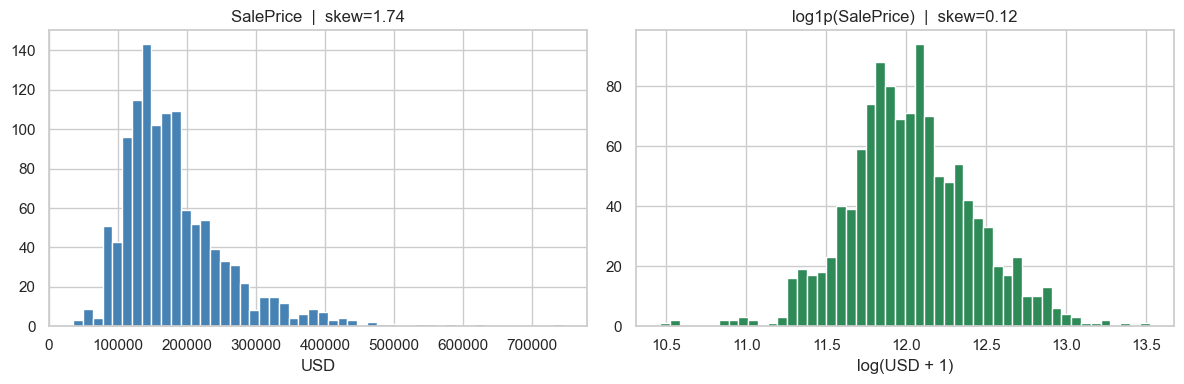

Skew original : 1.7431
Skew log1p    : 0.1249
Kurtosis orig : 5.4753
Kurtosis log1p: 0.7002


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'SalePrice  |  skew={train["SalePrice"].skew():.2f}')
axes[0].set_xlabel('USD')

log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p(SalePrice)  |  skew={log_price.skew():.2f}')
axes[1].set_xlabel('log(USD + 1)')

plt.tight_layout()
plt.show()

print(f'Skew original : {train["SalePrice"].skew():.4f}')
print(f'Skew log1p    : {log_price.skew():.4f}')
print(f'Kurtosis orig : {train["SalePrice"].kurtosis():.4f}')
print(f'Kurtosis log1p: {log_price.kurtosis():.4f}')

## 3. Valores Faltantes

In [6]:
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0] * 100

# Colunas onde NaN = "não tem" (definido pelo dicionário)
nan_means_none = [
    'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

classification = []
for col in missing.index:
    if col in nan_means_none:
        classification.append('NaN = não tem')
    else:
        classification.append('NaN = dado faltante')

missing_df = pd.DataFrame({
    'coluna': missing.index,
    '% missing': missing.values.round(1),
    'tipo': classification
})
print(missing_df.to_string(index=False))

      coluna  % missing                tipo
      PoolQC       99.5       NaN = não tem
 MiscFeature       96.1       NaN = não tem
       Alley       93.7       NaN = não tem
       Fence       80.1       NaN = não tem
  MasVnrType       58.5       NaN = não tem
 FireplaceQu       46.8       NaN = não tem
 LotFrontage       18.6 NaN = dado faltante
  GarageQual        5.5       NaN = não tem
GarageFinish        5.5       NaN = não tem
  GarageType        5.5       NaN = não tem
 GarageYrBlt        5.5 NaN = dado faltante
  GarageCond        5.5       NaN = não tem
    BsmtCond        2.4       NaN = não tem
    BsmtQual        2.4       NaN = não tem
BsmtExposure        2.4       NaN = não tem
BsmtFinType1        2.4       NaN = não tem
BsmtFinType2        2.4       NaN = não tem
  MasVnrArea        0.5 NaN = dado faltante
  Electrical        0.1 NaN = dado faltante


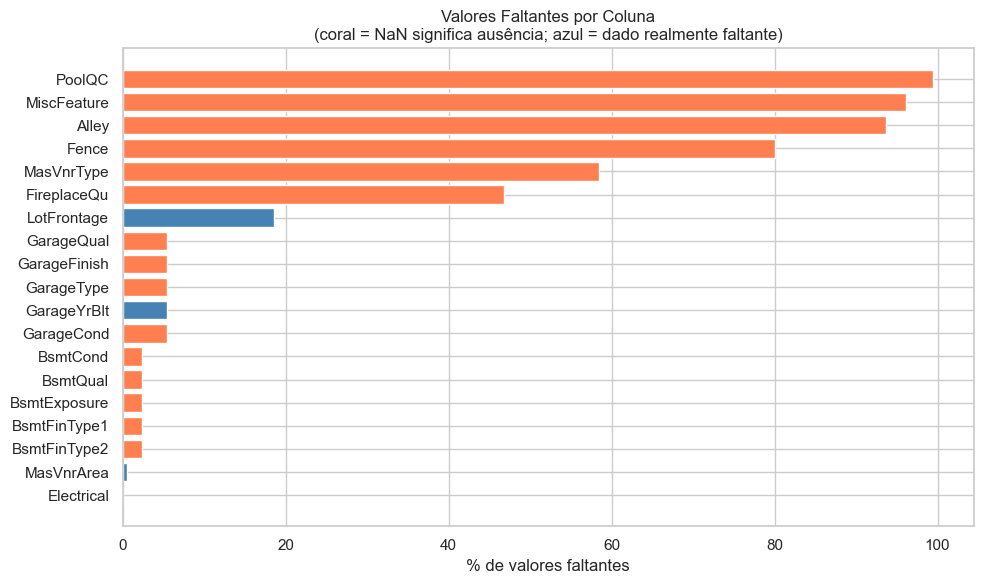

In [7]:
# Gráfico de barras dos faltantes
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if t == 'NaN = não tem' else 'steelblue' for t in missing_df['tipo']]
ax.barh(missing_df['coluna'], missing_df['% missing'], color=colors)
ax.set_xlabel('% de valores faltantes')
ax.set_title('Valores Faltantes por Coluna\n(coral = NaN significa ausência; azul = dado realmente faltante)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Correlações — Top 15 numéricas com SalePrice

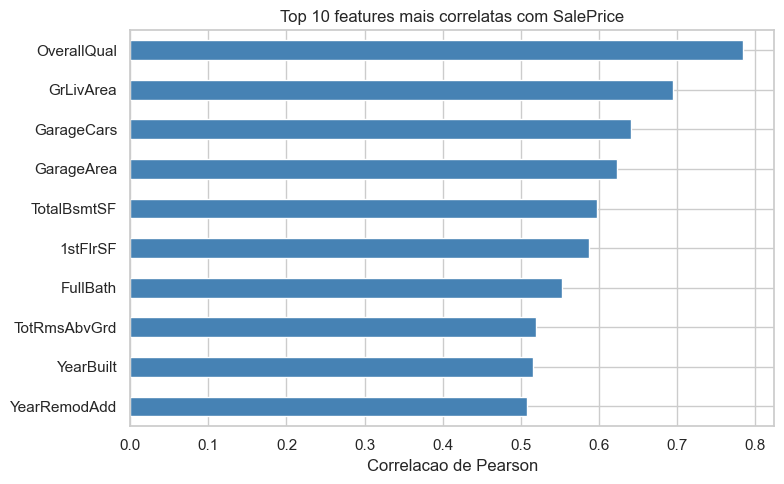


Top 10 correlacoes com SalePrice:
OverallQual     0.7856
GrLivArea       0.6957
GarageCars      0.6410
GarageArea      0.6241
TotalBsmtSF     0.5978
1stFlrSF        0.5879
FullBath        0.5525
TotRmsAbvGrd    0.5204
YearBuilt       0.5165
YearRemodAdd    0.5086
Name: SalePrice, dtype: float64


In [8]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_sp = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v > 0 else 'coral' for v in corr_sp.head(10).sort_values().values]
corr_sp.head(10).sort_values().plot.barh(ax=ax, color=colors)
ax.set_title('Top 10 features mais correlatas com SalePrice')
ax.set_xlabel('Correlacao de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 10 correlacoes com SalePrice:')
print(corr_sp.head(10).round(4))

## 5. Scatter e Outliers

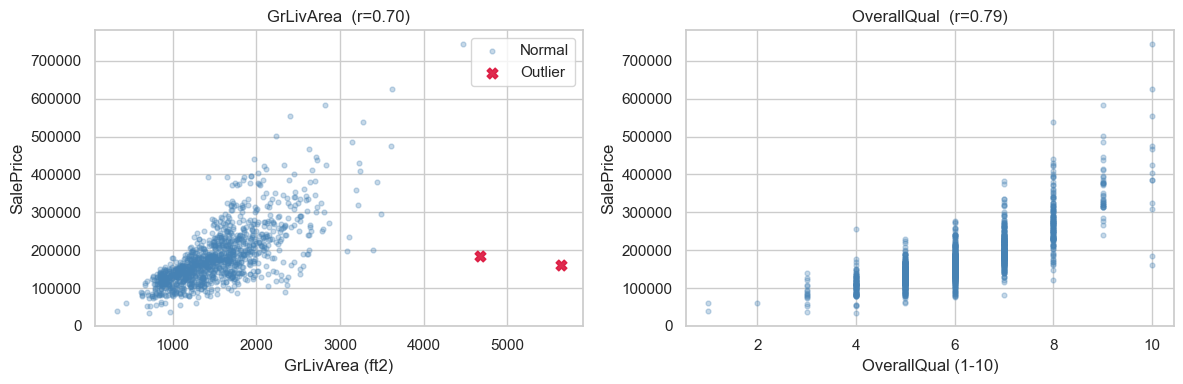

Outliers GrLivArea > 4000 & SalePrice < 300k: 2 linhas
     GrLivArea  SalePrice Neighborhood  OverallQual
365       4676     184750      Edwards           10
495       5642     160000      Edwards           10


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)
axes[0].scatter(
    train.loc[~outlier_mask, 'GrLivArea'], train.loc[~outlier_mask, 'SalePrice'],
    alpha=0.3, s=12, color='steelblue', label='Normal'
)
axes[0].scatter(
    train.loc[outlier_mask, 'GrLivArea'], train.loc[outlier_mask, 'SalePrice'],
    alpha=0.9, s=60, color='crimson', marker='X', label='Outlier'
)
r_gr = train[['GrLivArea', 'SalePrice']].dropna().corr().iloc[0, 1]
axes[0].set_title(f'GrLivArea  (r={r_gr:.2f})')
axes[0].set_xlabel('GrLivArea (ft2)')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

axes[1].scatter(train['OverallQual'], train['SalePrice'], alpha=0.3, s=12, color='steelblue')
r_oq = train[['OverallQual', 'SalePrice']].corr().iloc[0, 1]
axes[1].set_title(f'OverallQual  (r={r_oq:.2f})')
axes[1].set_xlabel('OverallQual (1-10)')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

outliers_df = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)]
print(f'Outliers GrLivArea > 4000 & SalePrice < 300k: {len(outliers_df)} linhas')
print(outliers_df[['GrLivArea', 'SalePrice', 'Neighborhood', 'OverallQual']])

## 6. Analise Categorica

In [10]:
cat_cols = train.select_dtypes(include='object').columns.tolist()

card_df = pd.DataFrame({
    'coluna': cat_cols,
    'n_categorias': [train[c].nunique() for c in cat_cols],
    'classe_dominante_pct': [
        train[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_cols
    ],
    'classe_dominante': [
        train[c].value_counts().index[0] for c in cat_cols
    ]
}).sort_values('n_categorias', ascending=False)

print('Cardinalidade das colunas categóricas:')
print(card_df.to_string(index=False))
print(f'\nColunas com classe dominante > 95%:')
print(card_df[card_df['classe_dominante_pct'] > 95][['coluna', 'classe_dominante', 'classe_dominante_pct']].to_string(index=False))

Cardinalidade das colunas categóricas:
       coluna  n_categorias  classe_dominante_pct classe_dominante
 Neighborhood            25             15.496575            NAmes
  Exterior2nd            16             35.102740          VinylSd
  Exterior1st            15             35.958904          VinylSd
   Condition1             9             85.958904             Norm
     SaleType             9             86.643836               WD
   HouseStyle             8             49.400685           1Story
   Condition2             8             99.058219             Norm
     RoofMatl             7             98.373288          CompShg
   Functional             7             92.808219              Typ
 BsmtFinType2             6             88.508772              Unf
    RoofStyle             6             77.568493            Gable
 BsmtFinType1             6             30.263158              Unf
SaleCondition             6             82.534247           Normal
      Heating          

C:\Users\vrios\AppData\Local\Temp\ipykernel_3012\2978914992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


## 8. Estratégia de Limpeza

### Outliers a remover
- **2 observações** com `GrLivArea > 4000` e `SalePrice < 300k` — imóveis grandes mas baratos, provavelmente venda em condições especiais. Removidos antes do treino.

### Variável alvo
- Aplicar `log1p(SalePrice)` no treino para normalizar a distribuição (skew ~1.88 → ~0.12). A métrica oficial é RMSLE, que equivale a RMSE no espaço log.

### Imputação por tipo de coluna
| Tipo | Estratégia |
|------|------------|
| NaN = "não tem" (Alley, PoolQC, Fence, FireplaceQu, Garage\*, Bsmt\*, MasVnrType) | `fillna('None')` antes do encoding |
| Numéricas com NaN real (LotFrontage, MasVnrArea, GarageYrBlt, etc.) | `SimpleImputer(strategy='median')` |
| Categóricas com NaN real (Electrical) | `SimpleImputer(strategy='most_frequent')` |

### Encoding planejado
| Tipo | Colunas | Encoding |
|------|---------|----------|
| Ordinal qualidade (Ex/Gd/TA/Fa/Po) | ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond, PoolQC | Mapeamento manual Ex=5…Po=1, None=0 |
| Nominal baixa cardinalidade | Alley, GarageType, Fence, MiscFeature, etc. | OneHotEncoder(handle_unknown='ignore') |
| Nominal alta cardinalidade (Neighborhood) | Neighborhood | OneHotEncoder |

### Escalonamento
- `StandardScaler` apenas nas colunas numéricas (após imputação).

### Features novas (`src/feature_engineering.py`)
| Feature | Descrição |
|---------|----------|
| `TotalSF` | TotalBsmtSF + 1stFlrSF + 2ndFlrSF |
| `TotalBath` | Full + 0.5×Half + BsmtFull + 0.5×BsmtHalf |
| `HouseAge` | YrSold − YearBuilt |
| `RemodAge` | YrSold − YearRemodAdd |
| `HasPool` | PoolArea > 0 |
| `HasGarage` | GarageArea > 0 |
| `HasFireplace` | Fireplaces > 0 |
| `HasBsmt` | TotalBsmtSF > 0 |